# Notebook 13 — Interpretability Report

**What drove the risk decision?**  
This notebook visualizes the RF feature importances, clause group contributions, and
the confusion matrix for the Phase 3 hybrid pipeline (Hybrid v2, RF backend).

All data is loaded live from model artifacts — no static numbers.

**Note:** If you retrained Phase 2 Legal-BERT (extended epochs / intensive LoRA), rerun
`python3 src/phase3/hybrid_eval_cli.py` so `reports/phase3/hybrid_eval.json` matches the current encoder; confusion-matrix cells below reflect that artifact plus live inference.

In [ ]:
# ── Cell 1: Path bootstrap ──────────────────────────────────────────────────
import sys
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src').exists()), None
)
assert PROJECT_ROOT, 'Could not locate project root containing src/'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: /Users/subhammahapatra/Downloads/agastya


In [2]:
# ── Cell 2: Imports ──────────────────────────────────────────────────────────
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

RF_MODEL_PATH  = PROJECT_ROOT / 'results/phase3/rf_reasoner.pkl'
HYBRID_EVAL    = PROJECT_ROOT / 'reports/phase3/hybrid_eval.json'
TEST_CSV       = PROJECT_ROOT / 'data/processed/test.csv'
print('Imports OK')

Imports OK


## 1. Load Model and Feature Importances

In [3]:
# ── Cell 3: Load RF and compute importances ───────────────────────────────────
from src.phase3.rf_reasoner import load_rf_reasoner, get_feature_importances

reasoner = load_rf_reasoner(str(RF_MODEL_PATH))
fi_df    = get_feature_importances(reasoner)

print(f'Model loaded. Feature space: {len(fi_df)} labels')
print(f'\nTop 10 most important clause types:')
display(fi_df.head(10)[['label', 'importance']].style.format({'importance': '{:.4f}'}))

Model loaded. Feature space: 41 labels

Top 10 most important clause types:


,label,importance
0,Anti-Assignment,0.1546
1,Cap On Liability,0.1445
2,Expiration Date,0.1294
3,License Grant,0.0534
4,Minimum Commitment,0.0529
5,Insurance,0.0483
6,Revenue/Profit Sharing,0.0408
7,Audit Rights,0.0397
8,Effective Date,0.0395
9,Governing Law,0.0348


## 2. Top-15 Feature Importance Chart

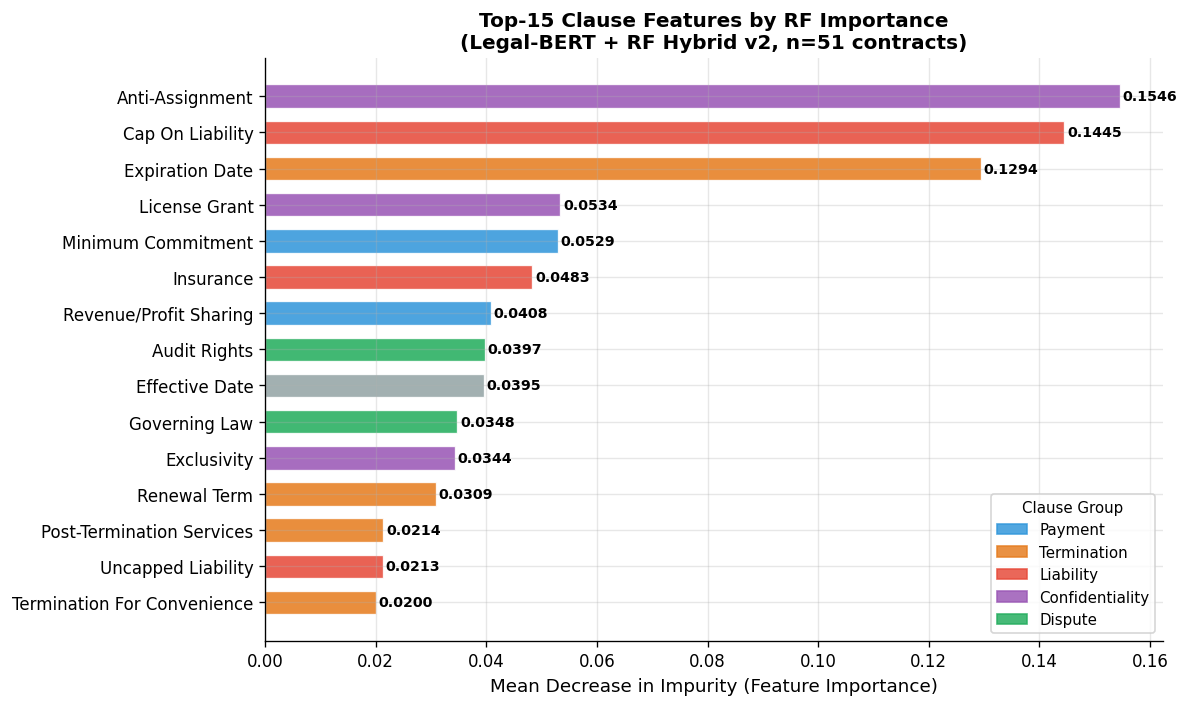

In [4]:
# ── Cell 4: Horizontal bar — top 15 feature importances ──────────────────────
top_n  = 15
plot_df = fi_df.head(top_n).copy()

# Color-code by clause group
PAYMENT_LABELS        = {'Revenue/Profit Sharing', 'Minimum Commitment', 'Price Restrictions',
                          'Liquidated Damages', 'Most Favored Nation', 'Volume Restriction',
                          'Unlimited/All-You-Can-Eat-License'}
TERMINATION_LABELS    = {'Termination For Convenience', 'Notice Period To Terminate Renewal',
                          'Post-Termination Services', 'Renewal Term', 'Expiration Date',
                          'Change Of Control'}
LIABILITY_LABELS      = {'Cap On Liability', 'Uncapped Liability', 'Warranty Duration',
                          'Insurance', 'Liquidated Damages'}
CONFIDENTIALITY_LABELS = {'Non-Compete', 'Non-Disparagement', 'No-Solicit Of Customers',
                           'No-Solicit Of Employees', 'Ip Ownership Assignment',
                           'Joint Ip Ownership', 'Source Code Escrow', 'Non-Transferable License',
                           'Irrevocable Or Perpetual License', 'Affiliate License-Licensee',
                           'Affiliate License-Licensor', 'License Grant',
                           'Competitive Restriction Exception', 'Exclusivity',
                           'Third Party Beneficiary', 'Rofr/Rofo/Rofn', 'Anti-Assignment'}
DISPUTE_LABELS        = {'Governing Law', 'Covenant Not To Sue', 'Audit Rights'}

GROUP_COLORS = {
    'Payment':         '#3498db',
    'Termination':     '#e67e22',
    'Liability':       '#e74c3c',
    'Confidentiality': '#9b59b6',
    'Dispute':         '#27ae60',
    'Other':           '#95a5a6',
}

def label_to_group(lbl):
    if lbl in PAYMENT_LABELS:         return 'Payment'
    if lbl in TERMINATION_LABELS:     return 'Termination'
    if lbl in LIABILITY_LABELS:       return 'Liability'
    if lbl in CONFIDENTIALITY_LABELS: return 'Confidentiality'
    if lbl in DISPUTE_LABELS:         return 'Dispute'
    return 'Other'

plot_df['group']  = plot_df['label'].apply(label_to_group)
plot_df['color']  = plot_df['group'].map(GROUP_COLORS)
plot_df = plot_df.sort_values('importance', ascending=True)  # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(plot_df['label'], plot_df['importance'],
               color=plot_df['color'], alpha=0.88, height=0.65,
               edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, plot_df['importance']):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8.5, fontweight='bold')

# Legend
patches = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.85, label=g)
           for g, c in GROUP_COLORS.items() if g != 'Other']
ax.legend(handles=patches, loc='lower right', fontsize=9, title='Clause Group',
          title_fontsize=9)

ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)', fontsize=11)
ax.set_title(f'Top-{top_n} Clause Features by RF Importance\n'
             f'(Legal-BERT + RF Hybrid v2, n=51 contracts)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/rf_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 3. Clause Group Importance (Aggregated)

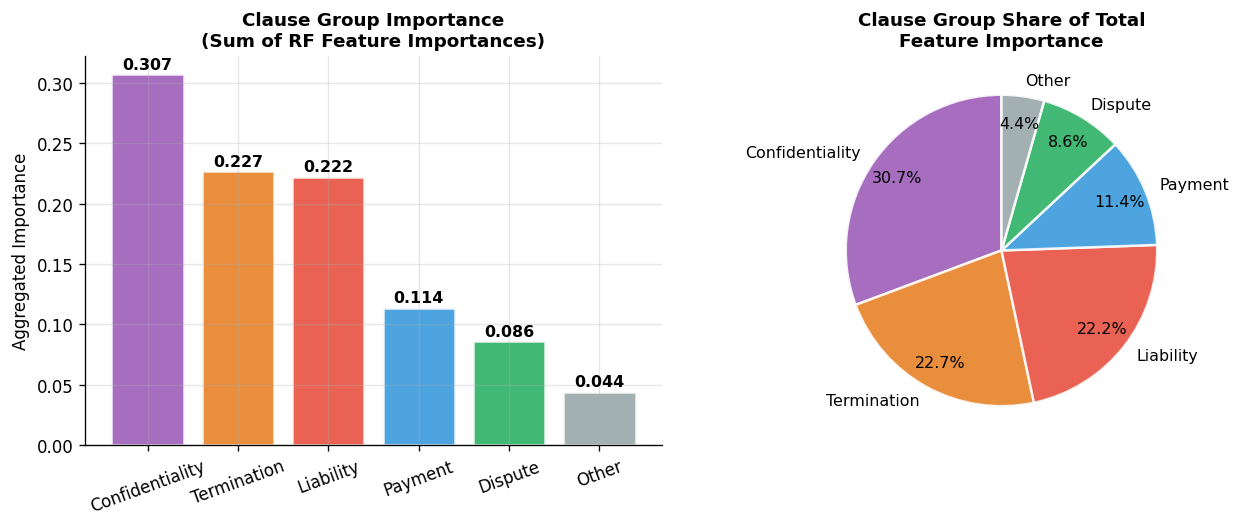

group
Confidentiality    0.306914
Termination        0.226536
Liability          0.222247
Payment            0.113804
Dispute            0.086246
Other              0.044253


In [ ]:
# ── Cell 5: Clause group aggregated importance ────────────────────────────────
full_fi = fi_df.copy()
full_fi['group'] = full_fi['label'].apply(label_to_group)
group_imp = full_fi.groupby('group')['importance'].sum().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Bar chart
colors_ = [GROUP_COLORS.get(g, '#95a5a6') for g in group_imp.index]
bars = ax1.bar(group_imp.index, group_imp.values, color=colors_, alpha=0.88,
               edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, group_imp.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
ax1.set_ylabel('Aggregated Importance', fontsize=10)
ax1.set_title('Clause Group Importance\n(Sum of RF Feature Importances)', fontsize=11, fontweight='bold')
ax1.tick_params(axis='x', labelrotation=20)

# Pie chart
ax2.pie(group_imp.values, labels=group_imp.index, colors=colors_,
        autopct='%1.1f%%', startangle=90, pctdistance=0.82,
        textprops={'fontsize': 9.5},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'alpha': 0.88})
ax2.set_title('Clause Group Share of Total\nFeature Importance', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/clause_group_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(group_imp.to_string())

## 4. Confusion Matrix

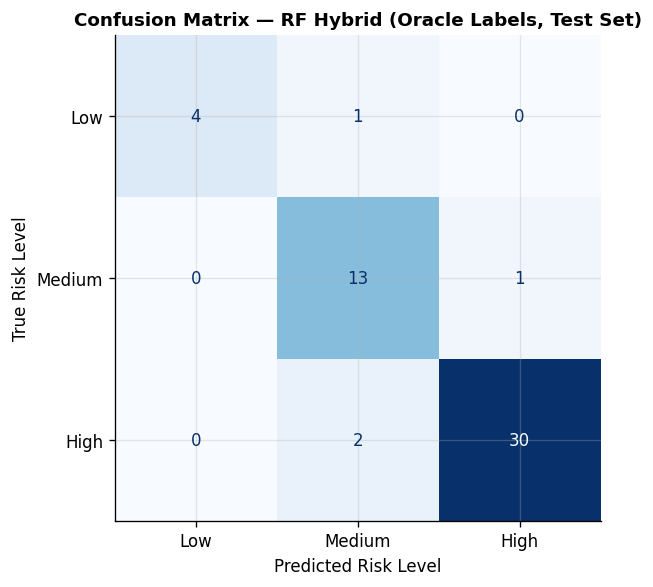


Classification Report:
              precision    recall  f1-score   support

         Low     1.0000    0.8000    0.8889         5
      Medium     0.8125    0.9286    0.8667        14
        High     0.9677    0.9375    0.9524        32

    accuracy                         0.9216        51
   macro avg     0.9267    0.8887    0.9026        51
weighted avg     0.9283    0.9216    0.9226        51



In [6]:
# ── Cell 6: Confusion matrix from test set ───────────────────────────────────
from src.phase3.rf_reasoner import predict_risk, build_feature_vector
from src.phase3.hybrid_eval import _derive_contract_risk

test_df = pd.read_csv(TEST_CSV)

y_true, y_pred = [], []
for filename, frame in test_df.groupby('filename'):
    labels = set(str(x).strip() for x in frame['label'].dropna())
    y_true.append(_derive_contract_risk(labels))
    result = predict_risk(reasoner, labels)
    y_pred.append(result['risk_level'])

risk_classes = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_true, y_pred, labels=risk_classes)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=risk_classes)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Confusion Matrix — RF Hybrid (Oracle Labels, Test Set)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted Risk Level', fontsize=10)
ax.set_ylabel('True Risk Level', fontsize=10)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, labels=risk_classes, digits=4))

## 5. Per-Class F1 Bar Chart

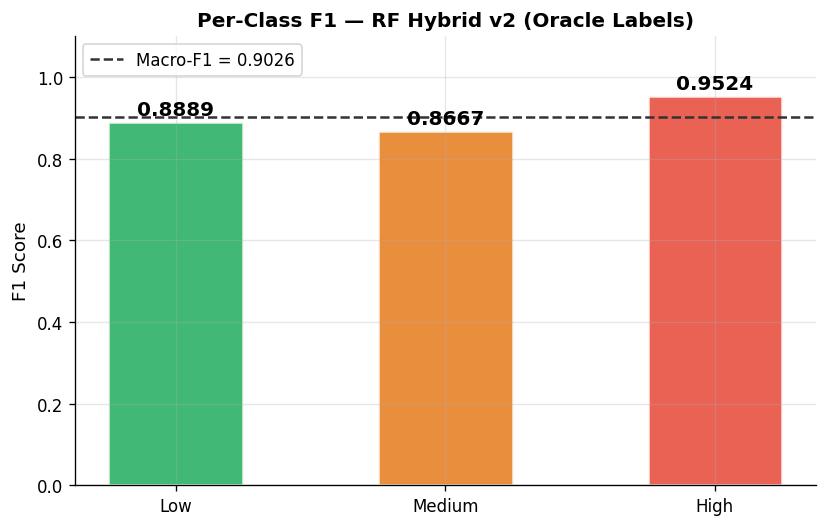

Low      F1: 0.8889
Medium   F1: 0.8667
High     F1: 0.9524
Macro    F1: 0.9026


In [7]:
# ── Cell 7: Per-class F1 breakdown ───────────────────────────────────────────
from sklearn.metrics import f1_score

per_class_f1 = f1_score(y_true, y_pred, labels=risk_classes, average=None)
macro_f1     = f1_score(y_true, y_pred, labels=risk_classes, average='macro')

fig, ax = plt.subplots(figsize=(7, 4.5))
class_colors = ['#27ae60', '#e67e22', '#e74c3c']
bars = ax.bar(risk_classes, per_class_f1, color=class_colors, alpha=0.88,
              width=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, per_class_f1):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.008,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(macro_f1, color='#333', linestyle='--', linewidth=1.5,
           label=f'Macro-F1 = {macro_f1:.4f}')

ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('Per-Class F1 — RF Hybrid v2 (Oracle Labels)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/per_class_f1.png',
            dpi=150, bbox_inches='tight')
plt.show()

for cls, f1 in zip(risk_classes, per_class_f1):
    print(f'{cls:<8} F1: {f1:.4f}')
print(f'Macro    F1: {macro_f1:.4f}')

## 6. Importance Distribution — Full Feature Heatmap

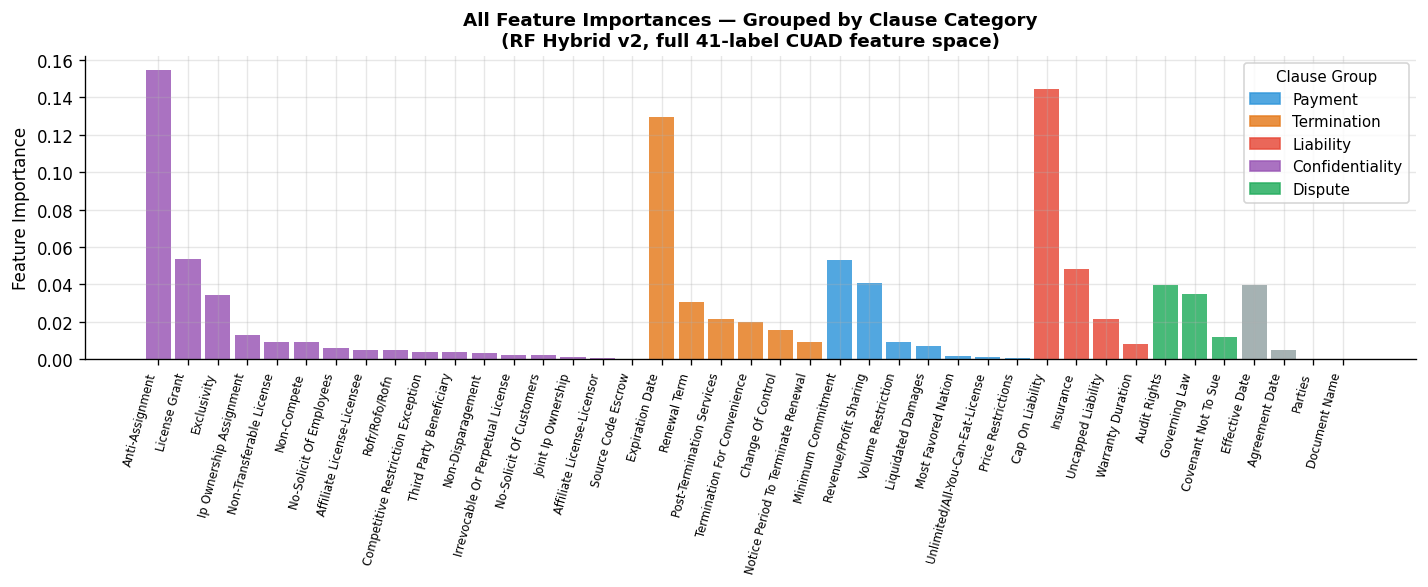

In [8]:
# ── Cell 8: Full feature importance heatmap ───────────────────────────────────
all_fi = fi_df.copy()
all_fi['group'] = all_fi['label'].apply(label_to_group)
all_fi = all_fi.sort_values(['group', 'importance'], ascending=[True, False])

group_order = ['Confidentiality', 'Termination', 'Payment', 'Liability', 'Dispute', 'Other']
all_fi['group_idx'] = all_fi['group'].map({g: i for i, g in enumerate(group_order)})
all_fi = all_fi.sort_values(['group_idx', 'importance'], ascending=[True, False])

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(all_fi)), all_fi['importance'].values,
               color=[GROUP_COLORS.get(g, '#95a5a6') for g in all_fi['group']],
               alpha=0.85, width=0.85, edgecolor='none')

ax.set_xticks(range(len(all_fi)))
ax.set_xticklabels(all_fi['label'].values, rotation=75, ha='right', fontsize=7)
ax.set_ylabel('Feature Importance', fontsize=10)
ax.set_title('All Feature Importances — Grouped by Clause Category\n'
             '(RF Hybrid v2, full 41-label CUAD feature space)',
             fontsize=11, fontweight='bold')

patches = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.85, label=g)
           for g, c in GROUP_COLORS.items() if g != 'Other']
ax.legend(handles=patches, loc='upper right', fontsize=9, title='Clause Group',
          title_fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports/phase3/figures/all_feature_importance_grouped.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Metric Summary Table

In [9]:
# ── Cell 9: Final summary table ───────────────────────────────────────────────
with open(HYBRID_EVAL) as f:
    hybrid = json.load(f)

summary = pd.DataFrame([
    {'Metric': 'Macro-F1',   'Value': hybrid['macro_f1'],  'Source': 'hybrid_eval.json'},
    {'Metric': 'Accuracy',   'Value': hybrid['accuracy'],  'Source': 'hybrid_eval.json'},
    {'Metric': 'Precision',  'Value': hybrid['precision'], 'Source': 'hybrid_eval.json'},
    {'Metric': 'Recall',     'Value': hybrid['recall'],    'Source': 'hybrid_eval.json'},
    {'Metric': 'n_contracts','Value': hybrid['n_contracts'],'Source': 'hybrid_eval.json'},
    {'Metric': 'Backend',    'Value': hybrid['reasoner_backend'], 'Source': 'hybrid_eval.json'},
])

display(summary.style
    .format({'Value': lambda v: f'{v:.4f}' if isinstance(v, float) else str(v)})
    .set_caption('Phase 3 Hybrid v2 — Final Reported Metrics')
    .hide(axis='index')
)

print('\nAll figures saved to:', PROJECT_ROOT / 'reports/phase3/figures/')

Metric,Value,Source
Macro-F1,0.8659,hybrid_eval.json
Accuracy,0.8824,hybrid_eval.json
Precision,0.8983,hybrid_eval.json
Recall,0.8411,hybrid_eval.json
n_contracts,51,hybrid_eval.json
Backend,rf,hybrid_eval.json



All figures saved to: /Users/subhammahapatra/Downloads/agastya/reports/phase3/figures


## Summary

| Visualization | What it shows |
|---|---|
| Top-15 Feature Importance | Which clause types have highest RF decision weight |
| Clause Group Importance | Aggregated contribution by category (Payment / Termination / etc.) |
| Confusion Matrix | Where the model makes errors across risk classes |
| Per-Class F1 | Low / Medium / High class-level performance |
| Full Feature Heatmap | Complete 41-label feature space sorted by group |

**Key finding:** Confidentiality and Termination clause types carry the most predictive signal
for contract-level risk classification, consistent with legal domain knowledge.